# lgb_model Training Notebook\nOptimized for IntrusionSense-IDS

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import multilabel_confusion_matrix, classification_report, confusion_matrix
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 1. Load the unified dataset
data_path = '../data/processed/master_dataset.csv'
df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
print("Label Distribution:")
print(df['Label'].value_counts())

Dataset shape: (166015, 79)
Label Distribution:
Label
BENIGN                        50000
PortScan                      50000
DoS Hulk                      45851
FTP-Patator                    7938
SSH-Patator                    5897
DoS GoldenEye                  2003
Web Attack � Brute Force       1507
DoS slowloris                  1089
DoS Slowhttptest               1055
Web Attack � XSS                652
Web Attack � Sql Injection       21
Heartbleed                        2
Name: count, dtype: int64


In [3]:
# 2. Preprocessing
def map_attack_label(label):
    label = str(label).strip()
    if label == 'BENIGN':
        return 0
    elif 'DoS' in label:
        return 1
    elif 'PortScan' in label:
        return 2
    elif 'Patator' in label:
        return 3
    elif 'Web Attack' in label:
        return 4
    else:
        return 5

if 'Label' not in df.columns:
    if 'Attack_Type' in df.columns:
        df = df.rename(columns={'Attack_Type': 'Label'})

y = df['Label'].apply(map_attack_label)
X = df.drop(columns=['Label'])

# Ensure numeric types
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [4]:
# 3. LightGBM Training
from lightgbm import LGBMClassifier

print("Training LightGBM...")
lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.134583 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13969
[LightGBM] [Info] Number of data points in the train set: 116210, number of used features: 66
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     15000
           1       1.00      1.00      1.00     15000
           2       1.00      1.00      1.00     15000
           3       1.00      1.00      1.00      4150
           4       0.99      0.98      0.99       654
           5       1.00      1.00      1.00         1

    accuracy                           1.00     49805
   macro avg       1.00      1.00      1.00     49805
weighted avg       1.00      1.00      1.00     49805



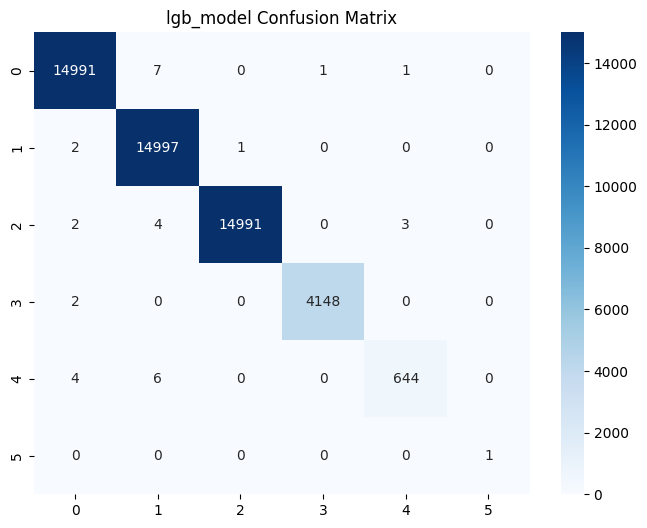

In [5]:
# 4. Evaluation
y_pred = lgb_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('lgb_model Confusion Matrix')
plt.show()

In [6]:
# 5. Export Models
os.makedirs('../src/models', exist_ok=True)
model_path = f'../src/models/multiClass_ids_model_lightgbm.pkl'
features_path = f'../src/models/model_features_lightgbm.pkl'

joblib.dump(lgb_model, model_path)
joblib.dump(list(X.columns), features_path)

print(f"Successfully saved model to {model_path}")
print(f"Successfully saved features to {features_path}")

Successfully saved model to ../src/models/multiClass_ids_model_lightgbm.pkl
Successfully saved features to ../src/models/model_features_lightgbm.pkl
